In [2]:
'''
Model Training
date: 2026-03-03
target: 训练模型，用户复购预测

训练两个模型：
1. 平销期模型:用1-3月预测4/5月
2. 促销期模型:用1-5月预测6月(618)

模型选择:XGBoost + LightGBM
评估指标:AUC, Precision, Recall, F1
'''

'\nModel Training\ndate: 2026-03-03\ntarget: 训练模型，用户复购预测\n\n训练两个模型：\n1. 平销期模型:用1-3月预测4/5月\n2. 促销期模型:用1-5月预测6月(618)\n\n模型选择:XGBoost + LightGBM\n评估指标:AUC, Precision, Recall, F1\n'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_val_predict
import warnings
warnings.filterwarnings('ignore')
 
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 加载4月、5月、6月的特征数据
data_month4 = pd.read_csv('../data/features/user_features_month4.csv')
data_month5 = pd.read_csv('../data/features/user_features_month5.csv')
data_month6 = pd.read_csv('../data/features/user_features_month6.csv')

print(f"4月数据: {data_month4.shape}")
print(f"5月数据: {data_month5.shape}")
print(f"6月数据: {data_month6.shape}")

# 特征列（排除user_id和label）
feature_cols = [col for col in data_month4.columns 
                if col not in ['user_id', 'label']]

print(f"\n特征数: {len(feature_cols)}")

4月数据: (544307, 73)
5月数据: (544307, 73)
6月数据: (544307, 73)

特征数: 71


## 数据集划分策略

模型1：平销期模型
- 训练集：4月数据（用1-3月特征预测4月）
- 验证集：从4月数据中分出20%
- 测试集：5月数据（用1-3月特征预测5月）

模型2：促销期模型（618）
- 训练集：4月+5月数据
- 验证集：从训练集中分出20%
- 测试集：6月数据（618大促）

#### 模型1：平销期模型

In [4]:
# 4月数据作为训练+验证
X_train_val = data_month4[feature_cols]
y_train_val = data_month4['label']

# 分割训练集和验证集（70:30）
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=0.3, 
    random_state=42,
    stratify=y_train_val  # 保持正负样本比例
)

# 5月数据作为测试集
X_test = data_month5[feature_cols]
y_test = data_month5['label']

print(f"训练集: {X_train.shape}, 正样本率: {y_train.mean()*100:.2f}%")
print(f"验证集: {X_val.shape}, 正样本率: {y_val.mean()*100:.2f}%")
print(f"测试集: {X_test.shape}, 正样本率: {y_test.mean()*100:.2f}%")

训练集: (381014, 71), 正样本率: 48.00%
验证集: (163293, 71), 正样本率: 48.00%
测试集: (544307, 71), 正样本率: 47.40%


##### 训练XGBoost模型

训练XGBoost模型...

XGBoost 模型性能:
训练集 AUC: 0.7048
验证集 AUC: 0.7010
测试集 AUC: 0.6677


<Figure size 1000x600 with 0 Axes>

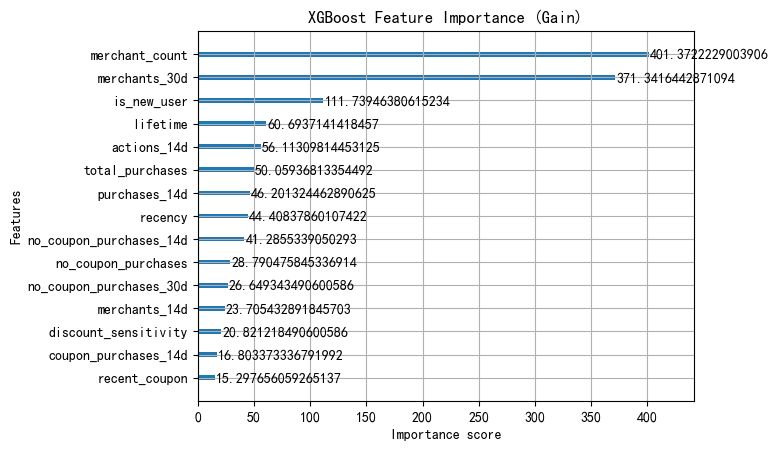

In [5]:
# XGBoost参数
xgb_params = {
    'max_depth': 6,
    'learning_rate': 0.05,             # 降低学习率，提升模型稳定性
    'n_estimators': 500,               # 增大树的数量，配合早停
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0,
    'early_stopping_rounds': 20,       # 增加早停耐心值
    'colsample_bytree': 0.8,           # 每棵树随机采样的特征比例，防止过拟合
    'subsample': 0.8                   # 训练每棵树使用的样本比例
}

# 训练模型
print("训练XGBoost模型...")
xgb_model = xgb.XGBClassifier(**xgb_params)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 预测概率 (用于 AUC 和 后续融合)
y_prob_train = xgb_model.predict_proba(X_train)[:, 1]
y_prob_val = xgb_model.predict_proba(X_val)[:, 1]
y_prob_test = xgb_model.predict_proba(X_test)[:, 1]

# 预测类别 (默认阈值 0.5)
y_pred_test = xgb_model.predict(X_test)

# 评估
print(f"\nXGBoost 模型性能:")
print(f"训练集 AUC: {roc_auc_score(y_train, y_prob_train):.4f}")
print(f"验证集 AUC: {roc_auc_score(y_val, y_prob_val):.4f}")
print(f"测试集 AUC: {roc_auc_score(y_test, y_prob_test):.4f}")

# 特征重要性分析
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=15, importance_type='gain')
plt.title('XGBoost Feature Importance (Gain)')
plt.show()

##### 训练LightGBM模型

训练LightGBM模型...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[134]	valid_0's auc: 0.700921

LightGBM 模型性能:
训练集 AUC: 0.7022
验证集 AUC: 0.7009
测试集 AUC: 0.6674


<Figure size 1000x600 with 0 Axes>

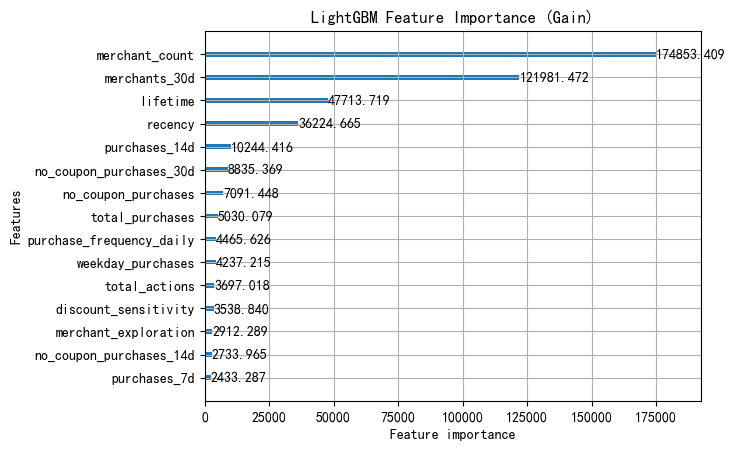

In [6]:
# LightGBM参数 (稍微调整以提升鲁棒性)
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 500,               # 增大迭代次数，依靠早停控制
    'learning_rate': 0.05,             # 降低学习率
    'max_depth': 6,
    'num_leaves': 31,                  # 限制叶子数防止过拟合
    'feature_fraction': 0.8,           # 特征采样
    'bagging_fraction': 0.8,           # 数据采样
    'bagging_freq': 5,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
}

# 训练模型
print("训练LightGBM模型...")
lgb_model = lgb.LGBMClassifier(**lgb_params)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20),
        lgb.log_evaluation(period=0)
    ]
)

# 预测概率
y_prob_train_lgb = lgb_model.predict_proba(X_train)[:, 1]
y_prob_val_lgb = lgb_model.predict_proba(X_val)[:, 1]
y_prob_test_lgb = lgb_model.predict_proba(X_test)[:, 1]

# 预测类别 (默认阈值 0.5)
y_pred_test_lgb = lgb_model.predict(X_test)

# 评估
print(f"\nLightGBM 模型性能:")
print(f"训练集 AUC: {roc_auc_score(y_train, y_prob_train_lgb):.4f}")
print(f"验证集 AUC: {roc_auc_score(y_val, y_prob_val_lgb):.4f}")
print(f"测试集 AUC: {roc_auc_score(y_test, y_prob_test_lgb):.4f}")

# 特征重要性分析
plt.figure(figsize=(10, 6))
lgb.plot_importance(lgb_model, max_num_features=15, importance_type='gain')
plt.title('LightGBM Feature Importance (Gain)')
plt.show()

##### 模型融合

In [ ]:
# ============================================================
# 高级融合策略 1：自适应权重寻优 (Adaptive Weight Search)
# 在验证集上以 0.01 为步长遍历 XGBoost 权重 w，LGBM 权重 = 1 - w
# ============================================================
print("=" * 60)
print("策略1：自适应权重寻优 (Adaptive Weight Search)")
print("=" * 60)

best_w      = 0.5
best_val_auc = 0.0
weight_results = []

for w in np.arange(0.0, 1.01, 0.01):
    w = round(w, 2)
    y_blend_val = w * y_prob_val + (1 - w) * y_prob_val_lgb
    val_auc = roc_auc_score(y_val, y_blend_val)
    weight_results.append({'xgb_weight': w, 'val_auc': val_auc})
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_w = w

print(f"最优 XGBoost 权重 w = {best_w:.2f}  (LGBM 权重 = {1 - best_w:.2f})")
print(f"验证集最高 AUC:       {best_val_auc:.4f}")

# 用最优权重在测试集上融合
y_prob_ensemble = best_w * y_prob_test + (1 - best_w) * y_prob_test_lgb
ensemble_auc    = roc_auc_score(y_test, y_prob_ensemble)
print(f"测试集融合 AUC:       {ensemble_auc:.4f}")

# 权重搜索曲线
weight_df = pd.DataFrame(weight_results)
plt.figure(figsize=(10, 4))
plt.plot(weight_df['xgb_weight'], weight_df['val_auc'], color='steelblue', lw=2)
plt.axvline(x=best_w, color='red', linestyle='--', label=f'最优权重 w={best_w:.2f}')
plt.xlabel('XGBoost 权重 w')
plt.ylabel('验证集 AUC')
plt.title('自适应权重搜索：验证集 AUC vs XGBoost 权重')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 高级融合策略 2：Stacking 堆叠泛化 (对比方案)
# 第一层：XGBoost + LightGBM   第二层：L2 正则化逻辑回归
# ============================================================
print("\n" + "=" * 60)
print("策略2：Stacking 堆叠泛化模型")
print("=" * 60)

# 基础估计器不含 early_stopping_rounds（兼容 StackingClassifier 的 CV 流程）
base_xgb = xgb.XGBClassifier(
    max_depth=6, learning_rate=0.05, n_estimators=300,
    objective='binary:logistic', eval_metric='auc',
    colsample_bytree=0.8, subsample=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
base_lgb = lgb.LGBMClassifier(
    objective='binary', metric='auc', boosting_type='gbdt',
    n_estimators=300, learning_rate=0.05, max_depth=6,
    num_leaves=31, feature_fraction=0.8, bagging_fraction=0.8,
    bagging_freq=5, random_state=42, n_jobs=-1, verbosity=-1
)

# 元模型：L2 正则化逻辑回归
meta_lr = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)

# StackingClassifier：cv=5 交叉验证生成元特征，训练元模型
stacking_clf = StackingClassifier(
    estimators=[('xgb', base_xgb), ('lgb', base_lgb)],
    final_estimator=meta_lr,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

print("训练 Stacking 模型（5折CV，耗时约数分钟）...")
stacking_clf.fit(X_train, y_train)

y_prob_val_stack  = stacking_clf.predict_proba(X_val)[:, 1]
y_prob_test_stack = stacking_clf.predict_proba(X_test)[:, 1]

stacking_val_auc  = roc_auc_score(y_val,  y_prob_val_stack)
stacking_test_auc = roc_auc_score(y_test, y_prob_test_stack)

print(f"Stacking 验证集 AUC: {stacking_val_auc:.4f}")
print(f"Stacking 测试集 AUC: {stacking_test_auc:.4f}")

print(f"\n--- AUC 汇总对比 ---")
print(f"单模型 XGBoost:                {roc_auc_score(y_test, y_prob_test):.4f}")
print(f"单模型 LightGBM:               {roc_auc_score(y_test, y_prob_test_lgb):.4f}")
print(f"软投票 (最优权重 w={best_w:.2f}):   {ensemble_auc:.4f}")
print(f"Stacking (LR Meta):            {stacking_test_auc:.4f}")

# ============================================================
# 高级融合策略 3：尤登指数最优阈值截断 (Youden's J Statistic)
# 基于验证集 ROC 曲线，找 TPR - FPR 最大的阈值，再用于测试集 F1
# ============================================================
print("\n" + "=" * 60)
print("策略3：尤登指数最优阈值 (Youden's J Statistic)")
print("=" * 60)

# 验证集融合概率（使用最优权重）
y_prob_val_ensemble = best_w * y_prob_val + (1 - best_w) * y_prob_val_lgb

# 在验证集上计算 ROC 曲线并求尤登指数 J = TPR - FPR
fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_prob_val_ensemble)
youden_j  = tpr_val - fpr_val
best_idx  = np.argmax(youden_j)
optimal_threshold = thresholds_val[best_idx]

print(f"最优阈值 (Youden's J): {optimal_threshold:.4f}")
print(f"最大尤登指数 J:        {youden_j[best_idx]:.4f}  "
      f"(TPR={tpr_val[best_idx]:.4f}, FPR={fpr_val[best_idx]:.4f})")

# 用最优阈值 vs 固定 0.5 对比测试集 F1
y_pred_youden = (y_prob_ensemble >= optimal_threshold).astype(int)
y_pred_05     = (y_prob_ensemble >= 0.5).astype(int)

print(f"\n--- 测试集 F1 对比 ---")
print(f"固定阈值 0.50:                   F1={f1_score(y_test, y_pred_05):.4f}")
print(f"尤登最优阈值 {optimal_threshold:.4f}:   "
      f"F1={f1_score(y_test, y_pred_youden):.4f}  "
      f"Precision={precision_score(y_test, y_pred_youden):.4f}  "
      f"Recall={recall_score(y_test, y_pred_youden):.4f}")

# 供后续可视化单元格使用
best_threshold = optimal_threshold
y_pred_final   = y_pred_youden

##### 可视化评估

In [ ]:
# ============================================================
# 可视化评估（4 子图）
# ============================================================
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ------ 子图1：测试集 ROC 曲线（软投票 + Stacking）+ 尤登最优点 ------
ax0 = fig.add_subplot(gs[0, 0])
fpr_ens, tpr_ens, _ = roc_curve(y_test, y_prob_ensemble)
fpr_stk, tpr_stk, _ = roc_curve(y_test, y_prob_test_stack)

ax0.plot(fpr_ens, tpr_ens, color='darkorange', lw=2,
         label=f'软投票 (AUC={ensemble_auc:.3f})')
ax0.plot(fpr_stk, tpr_stk, color='green', lw=2, linestyle='-.',
         label=f'Stacking (AUC={stacking_test_auc:.3f})')
ax0.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='随机')

# 标注尤登最优点（来自验证集，投影到测试集 ROC 上标记位置）
# 在测试集 ROC 上重新找最近的尤登点用于展示
youden_test  = tpr_ens - fpr_ens
youden_idx_t = np.argmax(youden_test)
ax0.scatter(fpr_ens[youden_idx_t], tpr_ens[youden_idx_t],
            color='red', zorder=5, s=100,
            label=f'Youden 点 (阈值≈{best_threshold:.3f})')

ax0.set_title('ROC 曲线对比（测试集）')
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.legend(fontsize=9)
ax0.grid(True, alpha=0.3)

# ------ 子图2：混淆矩阵（尤登最优阈值）------
import seaborn as sns
ax1 = fig.add_subplot(gs[0, 1])
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['预测不买', '预测买'], yticklabels=['实际不买', '实际买'])
ax1.set_title(f'混淆矩阵（尤登阈值 = {best_threshold:.4f}）')
ax1.set_xlabel('预测标签')
ax1.set_ylabel('真实标签')

# ------ 子图3：AUC 对比柱状图 ------
ax2 = fig.add_subplot(gs[1, 0])
models  = ['XGBoost', 'LightGBM', f'软投票\n(w={best_w:.2f})', 'Stacking\n(LR Meta)']
aucs    = [
    roc_auc_score(y_test, y_prob_test),
    roc_auc_score(y_test, y_prob_test_lgb),
    ensemble_auc,
    stacking_test_auc
]
colors  = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars    = ax2.bar(models, aucs, color=colors, width=0.5, edgecolor='white')
ax2.set_ylim(min(aucs) - 0.01, max(aucs) + 0.01)
ax2.set_ylabel('测试集 AUC')
ax2.set_title('各方案 AUC 对比')
for bar, auc in zip(bars, aucs):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
             f'{auc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# ------ 子图4：验证集尤登指数曲线 ------
ax3 = fig.add_subplot(gs[1, 1])
# 取前 N 个点防止 thresholds 数组过长导致显示混乱
plot_n = min(len(thresholds_val), 3000)
step   = max(1, len(thresholds_val) // plot_n)
ax3.plot(thresholds_val[::step], youden_j[::step], color='purple', lw=2)
ax3.axvline(x=best_threshold, color='red', linestyle='--',
            label=f'最优阈值 = {best_threshold:.4f}')
ax3.axhline(y=youden_j[best_idx], color='gray', linestyle=':', alpha=0.7)
ax3.scatter([best_threshold], [youden_j[best_idx]],
            color='red', zorder=5, s=100,
            label=f'最大 J = {youden_j[best_idx]:.4f}')
ax3.set_xlabel('阈值 (Threshold)')
ax3.set_ylabel('尤登指数 J = TPR - FPR')
ax3.set_title('验证集尤登指数曲线')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.suptitle('平销期模型：高级融合策略评估', fontsize=14, fontweight='bold', y=1.01)
plt.show()

# 特征重要性 Top 20（加权平均两模型）
plt.figure(figsize=(10, 6))
fi_ensemble = (xgb_model.feature_importances_ * best_w +
               lgb_model.feature_importances_ * (1 - best_w))
fi_df = pd.DataFrame({'feature': feature_cols, 'importance': fi_ensemble}) \
          .sort_values('importance', ascending=False).head(20)
sns.barplot(x='importance', y='feature', data=fi_df, palette='viridis')
plt.title(f'Top 20 Feature Importance（软投票融合权重 w={best_w:.2f}）')
plt.tight_layout()
plt.show()

#### 模型2：促销期模型

In [9]:
# 合并4月和5月数据作为训练集
train_data_promo = pd.concat([data_month4, data_month5], ignore_index=True)

X_train_promo = train_data_promo[feature_cols]
y_train_promo = train_data_promo['label']

# 分割训练验证集
X_train_p, X_val_p, y_train_p, y_val_p = train_test_split(
    X_train_promo, y_train_promo,
    test_size=0.2,
    random_state=42,
    stratify=y_train_promo
)

# 6月数据作为测试集
X_test_p = data_month6[feature_cols]
y_test_p = data_month6['label']

print(f"训练集: {X_train_p.shape}, 正样本率: {y_train_p.mean()*100:.2f}%")
print(f"验证集: {X_val_p.shape}, 正样本率: {y_val_p.mean()*100:.2f}%")
print(f"测试集(6月618): {X_test_p.shape}, 正样本率: {y_test_p.mean()*100:.2f}%")

训练集: (870891, 71), 正样本率: 47.70%
验证集: (217723, 71), 正样本率: 47.70%
测试集(6月618): (544307, 71), 正样本率: 47.29%


##### 训练XGBoost模型

In [11]:
# 训练XGBoost
print("\n训练XGBoost(促销期)...")
xgb_model_promo = xgb.XGBClassifier(**xgb_params)
xgb_model_promo.fit(
    X_train_p, y_train_p,
    eval_set=[(X_val_p, y_val_p)],
    verbose=False
)


训练XGBoost(促销期)...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

##### 训练LightGBM模型

In [12]:
# 训练LightGBM
print("训练LightGBM(促销期)...")
lgb_model_promo = lgb.LGBMClassifier(**lgb_params)
lgb_model_promo.fit(
    X_train_p, y_train_p,
    eval_set=[(X_val_p, y_val_p)],
    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)]
)

训练LightGBM（促销期）...
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[152]	valid_0's auc: 0.685103


LGBMClassifier(bagging_fraction=0.8, bagging_freq=5, feature_fraction=0.8,
               learning_rate=0.05, max_depth=6, metric='auc', n_estimators=500,
               n_jobs=-1, objective='binary', random_state=42, verbosity=-1)

##### 模型融合

In [ ]:
# ============================================================
# 促销期模型融合：自适应权重寻优 + 尤登指数最优阈值
# ============================================================

# ---- 计算验证集概率（用于权重寻优）----
y_prob_val_xgb_p = xgb_model_promo.predict_proba(X_val_p)[:, 1]
y_prob_val_lgb_p = lgb_model_promo.predict_proba(X_val_p)[:, 1]

# ---- 计算测试集概率 ----
y_pred_xgb_p = xgb_model_promo.predict_proba(X_test_p)[:, 1]
y_pred_lgb_p = lgb_model_promo.predict_proba(X_test_p)[:, 1]

# ---- 策略1：自适应权重寻优 ----
print("促销期：自适应权重寻优...")
best_w_p      = 0.5
best_val_auc_p = 0.0

for w in np.arange(0.0, 1.01, 0.01):
    w = round(w, 2)
    y_blend_val_p = w * y_prob_val_xgb_p + (1 - w) * y_prob_val_lgb_p
    val_auc_p = roc_auc_score(y_val_p, y_blend_val_p)
    if val_auc_p > best_val_auc_p:
        best_val_auc_p = val_auc_p
        best_w_p = w

print(f"最优 XGBoost 权重 w = {best_w_p:.2f}  (LGBM 权重 = {1 - best_w_p:.2f})")
print(f"验证集最高 AUC:       {best_val_auc_p:.4f}")

# 用最优权重融合测试集
y_pred_ensemble_p = best_w_p * y_pred_xgb_p + (1 - best_w_p) * y_pred_lgb_p
ensemble_auc_p    = roc_auc_score(y_test_p, y_pred_ensemble_p)
print(f"测试集融合 AUC:       {ensemble_auc_p:.4f}")

# ---- 策略2：尤登指数最优阈值 ----
print("\n促销期：尤登指数最优阈值...")
y_prob_val_ens_p = best_w_p * y_prob_val_xgb_p + (1 - best_w_p) * y_prob_val_lgb_p
fpr_val_p, tpr_val_p, thresholds_val_p = roc_curve(y_val_p, y_prob_val_ens_p)
youden_j_p        = tpr_val_p - fpr_val_p
best_idx_p        = np.argmax(youden_j_p)
optimal_thresh_p  = thresholds_val_p[best_idx_p]

print(f"最优阈值 (Youden's J): {optimal_thresh_p:.4f}")
print(f"最大尤登指数 J:        {youden_j_p[best_idx_p]:.4f}")

y_pred_promo_final = (y_pred_ensemble_p >= optimal_thresh_p).astype(int)
print(f"\n--- 促销期测试集指标 ---")
print(f"F1-Score:  {f1_score(y_test_p, y_pred_promo_final):.4f}")
print(f"Precision: {precision_score(y_test_p, y_pred_promo_final):.4f}")
print(f"Recall:    {recall_score(y_test_p, y_pred_promo_final):.4f}")

##### 可视化评估

In [14]:
# 评估
print(f"\n6月(618)测试集性能:")
print(f"  XGBoost AUC: {roc_auc_score(y_test_p, y_pred_xgb_p):.4f}")
print(f"  LightGBM AUC: {roc_auc_score(y_test_p, y_pred_lgb_p):.4f}")
print(f"  Ensemble AUC: {roc_auc_score(y_test_p, y_pred_ensemble_p):.4f}")


6月(618)测试集性能:
  XGBoost AUC: 0.6453
  LightGBM AUC: 0.6447
  Ensemble AUC: 0.6451


#### 平销期与促销期对比

In [15]:
comparison = pd.DataFrame({
    '数据集': ['5月(平销期)', '6月(618促销期)'],
    'XGBoost AUC': [
        roc_auc_score(y_test, y_pred_test),
        roc_auc_score(y_test_p, y_pred_xgb_p)
    ],
    'LightGBM AUC': [
        roc_auc_score(y_test, y_pred_test_lgb),
        roc_auc_score(y_test_p, y_pred_lgb_p)
    ],
    'Ensemble AUC': [
        ensemble_auc,
        roc_auc_score(y_test_p, y_pred_ensemble_p)
    ],
    '正样本率': [
        y_test.mean() * 100,
        y_test_p.mean() * 100
    ]
})

print(comparison.to_string(index=False))

       数据集  XGBoost AUC  LightGBM AUC  Ensemble AUC      正样本率
   5月(平销期)     0.623485      0.623221      0.667583 47.397333
6月(618促销期)     0.645307      0.644744      0.645085 47.288938


#### 模型保存

In [17]:
# 创建模型目录
import os
os.makedirs('../ml_models/regular_period', exist_ok=True)
os.makedirs('../ml_models/promotion_period', exist_ok=True)

# 保存平销期模型
with open('../ml_models/regular_period/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('../ml_models/regular_period/lgb_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)

# 保存促销期模型
with open('../ml_models/promotion_period/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model_promo, f)

with open('../ml_models/promotion_period/lgb_model.pkl', 'wb') as f:
    pickle.dump(lgb_model_promo, f)

# 保存模型元数据
metadata = {
    'regular_period': {
        'train_date': '2016-01-01 to 2016-03-31',
        'test_month': 5,
        'xgb_auc': roc_auc_score(y_test, y_pred_test),
        'lgb_auc': roc_auc_score(y_test, y_pred_test_lgb),
        'ensemble_auc': ensemble_auc,
        'best_threshold': best_threshold,
        'feature_count': len(feature_cols)
    },
    'promotion_period': {
        'train_date': '2016-01-01 to 2016-05-31',
        'test_month': 6,
        'xgb_auc': roc_auc_score(y_test_p, y_pred_xgb_p),
        'lgb_auc': roc_auc_score(y_test_p, y_pred_lgb_p),
        'ensemble_auc': roc_auc_score(y_test_p, y_pred_ensemble_p),
        'feature_count': len(feature_cols)
    }
}

with open('../ml_models/model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("平销期模型已保存: ml_models/regular_period/")
print("促销期模型已保存: ml_models/promotion_period/")
print("模型元数据已保存: ml_models/model_metadata.pkl")

平销期模型已保存: ml_models/regular_period/
促销期模型已保存: ml_models/promotion_period/
模型元数据已保存: ml_models/model_metadata.pkl
